In [25]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.image as mpimg
from PIL import Image
import struct
import shutil
import os

# Useful functions for later execution
def display_image(image):
    img = mpimg.imread(image)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    pixels = img.shape[0] * img.shape[1]
    bits_per_pixel = 3
    bytes_to_conceal = (pixels * bits_per_pixel)/8
    
    print(f'Height: {img.shape[0]} pixels - Width: {img.shape[1]} pixels')
    print(f'Amount of pixels: {display_count(pixels)} pixels')
    print(f'Capacity of bytes to conceal: ~{display_count(bytes_to_conceal)}B')
    print(display_file_size(image))

def bytes_to_bits(data):
    for byte in data:
        for i in range(7, -1, -1):
            yield (byte >> i) & 1

def bits_to_bytes(bits):
    byte = 0
    count = 0
    for bit in bits:
        byte = (byte << 1) | bit
        count += 1
        if count == 8:
            yield byte
            byte = 0
            count = 0

def display_file_size(file_path):
    size = os.path.getsize(file_path)
    units = ["B", "KB", "MB", "GB", "TB"]
    for unit in units:
        if size < 1024 or unit == units[-1]:
             return f"File size: {size:.2f} {unit}"
        size /= 1024

def display_count(amount):
    units = [" ","K", "M"]
    for unit in units:
        if amount < 1000 or unit == units[-1]:
            return f"{amount:.2f} {unit}"
        amount /= 1000

# Backup cover image for future use
cover_png_bk = '../../misc/BeautifulDucksBk.png'
cover_png = '../../misc/BeautifulDucks.png'
shutil.copy(cover_png_bk,cover_png)

'../../misc/BeautifulDucks.png'

# Concealing a message on a PNG with LSB steganography
Least Significant Bit (LSB) steganography is a technique used to hide secret data inside images by modifying the least significant bits of the data that represents the image.

In PNG, each pixel is represented by color channels such as Red, Green, and Blue (RGB). Each channel is stored as an 8-bit number (0–255). The least significant bit is the last bit in that binary number and contributes the smallest possible change to the color value.

LSB steganography works by replacing these least significant bits with bits from the secret data. Because changing the last bit only alters the color value by ±1, the visual difference is usually imperceptible to the human eye.

For example:

    Original pixel value (R channel):
    10110110  (182)
    
    After embedding one secret bit (1):
    10110111  (183)

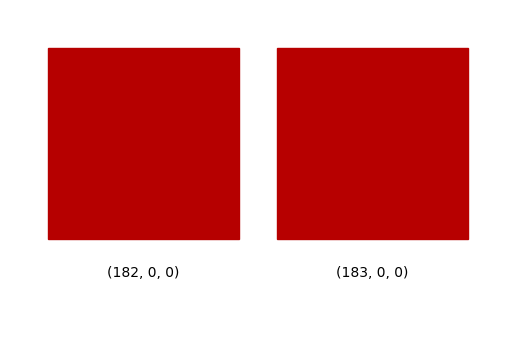

In [26]:
color1 = (182/255, 0/255, 0/255)
color2 = (183/255, 0/255, 0/255)

fig, ax = plt.subplots()

square1 = Rectangle((0, 0), 1, 1, color=color1)
ax.add_patch(square1)
square2 = Rectangle((1.2, 0), 1, 1, color=color2)
ax.add_patch(square2)

ax.text(0.5, -0.2, "(182, 0, 0)", ha="center")
ax.text(1.7, -0.2, "(183, 0, 0)", ha="center")
ax.set_xlim(-0.2, 2.4)
ax.set_ylim(-0.5, 1.2)
ax.set_aspect('equal')
ax.axis('off')
plt.show()

By repeating this process across many pixels, a large amount of data can be concealed within the image. During extraction, the program simply reads the least significant bits from the pixels in the same order to reconstruct the hidden message.

LSB steganography is simple and effective for lossless formats such as PNG, but it is less reliable for compressed formats like JPEG, where compression may alter or remove the modified bits.

## Original image

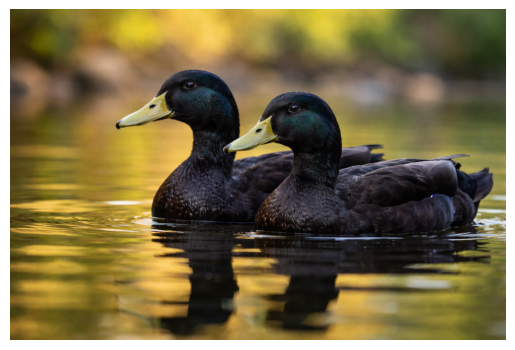

Height: 1024 pixels - Width: 1536 pixels
Amount of pixels: 1.57 M pixels
Capacity of bytes to conceal: ~589.82 KB
File size: 2.10 MB


In [27]:
display_image(cover_png)

## Let's hide a file "inside" these beautiful ducks
The secret file needs to be converted into bits in order to apply the LSB steganography.

In [18]:
secret_file = '../../misc/hiding/TheSecretBehindBlackDucks.png'
with open(secret_file, "rb") as f:
    secret = f.read()

payload = struct.pack(">I", len(secret)) + secret
secret_bits = list(bytes_to_bits(payload))

We will hide the bits of this secret file into the R,G,B channel of each pixel of the PNG.

We verify that the secret size is small enough to be concealed inside the cover image.

In [19]:
img = Image.open(cover_png)
pixels = list(img.get_flattened_data())

capacity = len(pixels) * 3

if len(secret_bits) > capacity:
    raise ValueError("Cover image too small for payload.")

Now, pixel by pixel we change the LSB of each channel. This is done with bit operations, we clear the last bit of the channel and then assign the secret bit to it.

In [20]:
new_pixels = []
bit_index = 0

for pixel in pixels:

    r, g, b = pixel[:3]

    if bit_index < len(secret_bits):
        r = (r & ~1) | secret_bits[bit_index]
        bit_index += 1

    if bit_index < len(secret_bits):
        g = (g & ~1) | secret_bits[bit_index]
        bit_index += 1

    if bit_index < len(secret_bits):
        b = (b & ~1) | secret_bits[bit_index]
        bit_index += 1

    new_pixels.append((r, g, b))

Saving the image after LSB manipulation.

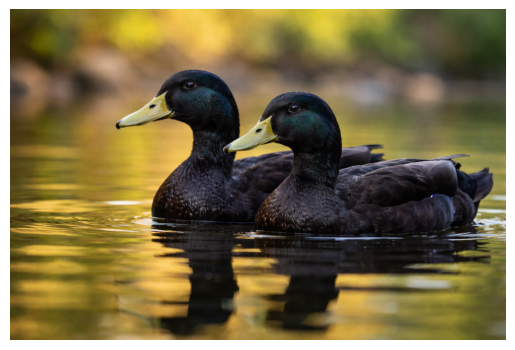

Height: 1024 pixels - Width: 1536 pixels
Amount of pixels: 1.57 M pixels
Capacity of bytes to conceal: ~589.82 KB
File size: 2.10 MB


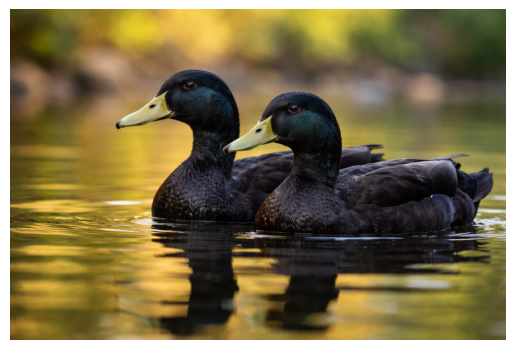

Height: 1024 pixels - Width: 1536 pixels
Amount of pixels: 1.57 M pixels
Capacity of bytes to conceal: ~589.82 KB
File size: 1.94 MB


In [21]:
cover_png_plus_secret = "../../misc/BeautifulDucksHoldingASecret.png"

img.putdata(new_pixels)
img.save(cover_png_plus_secret)

display_image(cover_png)
display_image(cover_png_plus_secret)

## Let's find out what the black ducks are hiding
We will retrieve the secret bit by bit from each pixel channel.

In [22]:
img = Image.open(cover_png_plus_secret)
pixels = list(img.get_flattened_data())

bits = []

for pixel in pixels:
    r, g, b = pixel[:3]

    bits.append(r & 1)
    bits.append(g & 1)
    bits.append(b & 1)

data = bytes(bits_to_bytes(bits))

size = struct.unpack(">I", data[:4])[0]

payload = data[4:4 + size]

Revealing the secret now, drumb roll please 🥁...

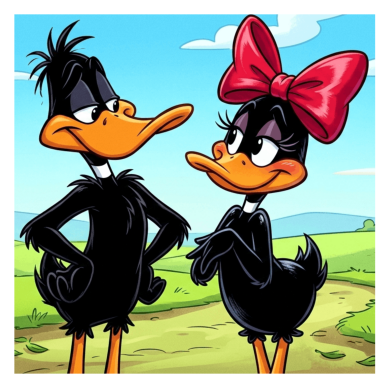

Height: 760 pixels - Width: 760 pixels
Amount of pixels: 577.60 K pixels
Capacity of bytes to conceal: ~216.60 KB
File size: 165.22 KB


In [23]:
revealed_secret = "../../misc/WhatASurprise.png"
with open(revealed_secret, "wb") as f:
    f.write(payload)

display_image(revealed_secret)

In [24]:
os.remove(cover_png)
os.remove(cover_png_plus_secret)
os.remove(revealed_secret)